# Banking API Failure Prediction — End-to-End Demo
**Full workflow:** Generate random telemetry → Preprocess → Run LSTM → Show results

Outputs:
- Per-API failure probability scores
- Risk level labels (Low / Medium / High)
- ROC curve & AUC on demo data
- Timestep-by-timestep prediction table

## Cell 1 — Imports & Configuration

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
warnings.filterwarnings('ignore')

# ── Paths (adjust if your project root differs) ───────────────────────────────
MODEL_PATH   = '../models/stress_test_best_model.pth'
RESULTS_PATH = '../models/demo_results.json'

# ── Model hyperparameters (must match run_lstm_training.py exactly) ───────────
FEATURE_COLS = [
    'response_time', 'status_code', 'request_count', 'hour', 'day_of_week',
    'response_time_rolling_mean', 'response_time_rolling_std',
    'error_rate_rolling', 'response_time_variance', 'error_volatility',
]
HIDDEN_SIZE        = 64
NUM_LAYERS         = 2
SEQUENCE_LENGTH    = 30
PREDICTION_HORIZONS = [1, 5, 15]

# ── Risk thresholds ───────────────────────────────────────────────────────────
RISK_LOW    = 0.35
RISK_HIGH   = 0.65

# Banking API types to simulate
API_TYPES = ['Stock Price API', 'Forex API', 'Crypto API',
             'Market Data API', 'Transaction API']

print("✅ Configuration loaded.")
print(f"   Model path : {MODEL_PATH}")
print(f"   Features   : {len(FEATURE_COLS)}")
print(f"   Horizons   : {PREDICTION_HORIZONS} steps ahead")

✅ Configuration loaded.
   Model path : ../models/stress_test_best_model.pth
   Features   : 10
   Horizons   : [1, 5, 15] steps ahead


## Cell 2 — Generate Random Banking API Telemetry

In [2]:
def generate_demo_telemetry(n_minutes=500, api_name='Stock Price API', seed=None):
    """
    Generate realistic random banking API telemetry for demo purposes.
    Includes market-hour patterns, failure clustering, and volatility spikes.
    """
    if seed is not None:
        np.random.seed(seed)

    timestamps = pd.date_range('2025-01-06 08:00', periods=n_minutes, freq='1min')
    hour = timestamps.hour.values
    dow  = timestamps.dayofweek.values

    # Response time: base exponential + time-of-day effect + noise
    base_rt       = np.random.exponential(80, n_minutes)
    hour_effect   = 40 * np.sin(2 * np.pi * hour / 24)
    spike_mask    = np.random.random(n_minutes) < 0.03          # 3% random spikes
    spike_values  = np.random.exponential(300, n_minutes)
    response_time = np.maximum(10, base_rt + hour_effect
                               + spike_mask * spike_values)

    # Status codes: more errors during off-peak + random burst failures
    is_peak   = ((hour >= 9) & (hour <= 16) & (dow < 5))
    error_prob = np.where(is_peak, 0.08, 0.18)

    # Inject a failure burst window (realistic outage simulation)
    burst_start = n_minutes // 3
    burst_end   = burst_start + 40
    error_prob[burst_start:burst_end] = np.clip(
        error_prob[burst_start:burst_end] + 0.45, 0, 0.95
    )

    status_codes = np.where(
        np.random.random(n_minutes) < error_prob,
        np.random.choice([400, 404, 500, 503], n_minutes),
        np.random.choice([200, 201],            n_minutes, p=[0.7, 0.3])
    )
    success = (status_codes < 400).astype(int)

    # Failure clustering: failures beget nearby failures
    for idx in np.where(success == 0)[0]:
        for offset in range(1, 6):
            if idx + offset < n_minutes and np.random.random() < 0.25:
                success[idx + offset] = 0

    request_count = np.random.poisson(40 + 30 * is_peak.astype(int), n_minutes)

    df = pd.DataFrame({
        'timestamp':    timestamps,
        'api_name':     api_name,
        'response_time': response_time,
        'status_code':  status_codes,
        'success':      success,
        'request_count': request_count,
        'hour':         hour,
        'day_of_week':  dow,
    })

    # Rolling features (same as training pipeline)
    df['response_time_rolling_mean'] = (df['response_time']
                                        .rolling(60, min_periods=1).mean())
    df['response_time_rolling_std']  = (df['response_time']
                                        .rolling(60, min_periods=1).std()
                                        .fillna(0))
    df['error_rate_rolling']         = ((1 - df['success'])
                                        .rolling(60, min_periods=1).mean())
    df['response_time_variance']     = df['response_time_rolling_std'] ** 2
    df['error_volatility']           = np.random.exponential(0.1, n_minutes)

    return df


# Generate telemetry for all 5 API types
all_dfs = []
for i, api in enumerate(API_TYPES):
    df_api = generate_demo_telemetry(n_minutes=500, api_name=api, seed=42 + i)
    all_dfs.append(df_api)

demo_df = pd.concat(all_dfs, ignore_index=True)
print(f"✅ Generated telemetry: {len(demo_df):,} rows across {len(API_TYPES)} APIs")
print(f"   Date range  : {demo_df['timestamp'].min()} → {demo_df['timestamp'].max()}")
print(f"   Failure rate: {1 - demo_df['success'].mean():.2%}\n")
display(demo_df.head(3))

✅ Generated telemetry: 2,500 rows across 5 APIs
   Date range  : 2025-01-06 08:00:00 → 2025-01-06 16:19:00
   Failure rate: 22.76%



,timestamp,api_name,response_time,status_code,success,request_count,hour,day_of_week,response_time_rolling_mean,response_time_rolling_std,error_rate_rolling,response_time_variance,error_volatility
0,2025-01-06 08:00:00,Stock Price API,72.182463,200,1,42,8,0,72.182463,0.000000,0.000000,0.000000,0.272922
1,2025-01-06 08:01:00,Stock Price API,275.450731,201,1,35,8,0,173.816597,143.732370,0.000000,20658.994241,0.028885
2,2025-01-06 08:02:00,Stock Price API,139.980672,500,0,57,8,0,162.537955,103.494543,0.333333,10711.120402,0.012834


## Cell 3 — Preprocess & Build Sequences

In [3]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    """Sequence dataset with fitted StandardScaler."""
    def __init__(self, data_array, targets_array, sequence_length,
                 horizons, scaler=None):
        if scaler is None:
            self.scaler  = StandardScaler()
            data_array   = self.scaler.fit_transform(data_array)
        else:
            self.scaler  = scaler
            data_array   = self.scaler.transform(data_array)

        self._data     = data_array.astype(np.float32)
        self._targets  = targets_array.astype(np.float32)
        self.seq_len   = sequence_length
        self.horizons  = horizons
        self.max_start = (len(self._data)
                          - self.seq_len - max(self.horizons) + 1)

    def __len__(self):
        return max(0, self.max_start)

    def __getitem__(self, idx):
        seq     = self._data[idx: idx + self.seq_len].copy()
        targets = [float(1 - self._targets[idx + self.seq_len + h - 1])
                   for h in self.horizons]
        return {
            'sequence':  torch.from_numpy(seq),
            'targets':   torch.tensor(targets, dtype=torch.float32),
            'row_index': idx + self.seq_len   # original row this sequence ends at
        }


# Build one dataset per API (separate scaler per API for fair comparison)
api_datasets = {}
for api in API_TYPES:
    sub = demo_df[demo_df['api_name'] == api].copy().reset_index(drop=True)
    sub[FEATURE_COLS] = sub[FEATURE_COLS].fillna(0)
    X = sub[FEATURE_COLS].to_numpy(dtype=np.float64)
    y = sub['success'].to_numpy(dtype=np.float32)
    ds = TimeSeriesDataset(X, y, SEQUENCE_LENGTH, PREDICTION_HORIZONS)
    api_datasets[api] = {'dataset': ds, 'df': sub}
    print(f"  {api:<22} → {len(ds):>4} sequences  "
          f"(failure rate: {1 - sub['success'].mean():.2%})")

print(f"\n✅ Preprocessing complete.")

  Stock Price API        →  456 sequences  (failure rate: 22.60%)
  Forex API              →  456 sequences  (failure rate: 18.60%)
  Crypto API             →  456 sequences  (failure rate: 26.00%)
  Market Data API        →  456 sequences  (failure rate: 24.40%)
  Transaction API        →  456 sequences  (failure rate: 22.20%)

✅ Preprocessing complete.


## Cell 4 — Load LSTM Model & Run Inference

In [4]:
class MultiHorizonLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers,
                 output_size, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=False,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(self.dropout(out[:, -1, :]))


# Load trained weights
assert os.path.exists(MODEL_PATH), f"Model not found at {MODEL_PATH}"
model = MultiHorizonLSTM(len(FEATURE_COLS), HIDDEN_SIZE,
                         NUM_LAYERS, len(PREDICTION_HORIZONS))
model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
model.eval()
print(f"✅ Model loaded from {MODEL_PATH}\n")


def run_inference(dataset):
    """Run LSTM on a dataset, return probabilities, targets, row indices."""
    loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    all_probs, all_targets, all_idx = [], [], []
    with torch.no_grad():
        for batch in loader:
            probs = torch.sigmoid(model(batch['sequence']))
            all_probs.append(probs.numpy())
            all_targets.append(batch['targets'].numpy())
            all_idx.extend(batch['row_index'].tolist())
    return (np.vstack(all_probs),
            np.vstack(all_targets),
            np.array(all_idx))


# Run inference per API
for api in API_TYPES:
    probs, targets, idx = run_inference(api_datasets[api]['dataset'])
    api_datasets[api]['probs']   = probs
    api_datasets[api]['targets'] = targets
    api_datasets[api]['idx']     = idx
    print(f"  {api:<22} → inference done  "
          f"({len(probs)} predictions)")

print("\n✅ Inference complete for all APIs.")

✅ Model loaded from ../models/stress_test_best_model.pth

  Stock Price API        → inference done  (456 predictions)
  Forex API              → inference done  (456 predictions)
  Crypto API             → inference done  (456 predictions)
  Market Data API        → inference done  (456 predictions)
  Transaction API        → inference done  (456 predictions)

✅ Inference complete for all APIs.


## Cell 5 — Timestep-by-Timestep Prediction Table

In [5]:
def risk_label(prob):
    if prob >= RISK_HIGH:
        return 'HIGH  🔴'
    elif prob >= RISK_LOW:
        return 'MEDIUM 🟡'
    else:
        return 'LOW   🟢'


# Build full prediction table across all APIs
rows = []
for api in API_TYPES:
    probs   = api_datasets[api]['probs']
    targets = api_datasets[api]['targets']
    idx     = api_datasets[api]['idx']
    sub_df  = api_datasets[api]['df']

    for i, row_i in enumerate(idx):
        ts = sub_df.loc[row_i, 'timestamp']
        actual_failure = int(1 - sub_df.loc[row_i, 'success'])
        rows.append({
            'timestamp':           pd.Timestamp(ts),
            'api_name':            api,
            'prob_h1':             round(float(probs[i, 0]), 4),
            'prob_h5':             round(float(probs[i, 1]), 4),
            'prob_h15':            round(float(probs[i, 2]), 4),
            'avg_prob':            round(float(probs[i].mean()), 4),
            'risk_level':          risk_label(float(probs[i, 0])),
            'actual_failure':      actual_failure,
        })

pred_table = pd.DataFrame(rows)

# Show a sample — 5 rows per API covering the failure burst window
sample_rows = []
for api in API_TYPES:
    sub = pred_table[pred_table['api_name'] == api]
    high_risk = sub[sub['risk_level'].str.startswith('HIGH')]
    sample_rows.append(high_risk.head(3) if len(high_risk) >= 3 else sub.head(3))

sample = pd.concat(sample_rows).reset_index(drop=True)

print("=" * 90)
print("  TIMESTEP-BY-TIMESTEP PREDICTION TABLE (sample — high-risk rows per API)")
print("=" * 90)
display(sample[[
    'timestamp', 'api_name',
    'prob_h1', 'prob_h5', 'prob_h15',
    'avg_prob', 'risk_level', 'actual_failure'
]].rename(columns={
    'prob_h1':  'P(fail @1)',
    'prob_h5':  'P(fail @5)',
    'prob_h15': 'P(fail @15)',
    'avg_prob': 'Avg Prob',
}))

# Save full table
pred_table.to_csv('../models/demo_predictions.csv', index=False)
print(f"\n✅ Full prediction table saved → models/demo_predictions.csv  "
      f"({len(pred_table):,} rows)")

  TIMESTEP-BY-TIMESTEP PREDICTION TABLE (sample — high-risk rows per API)


,timestamp,api_name,P(fail @1),P(fail @5),P(fail @15),Avg Prob,risk_level,actual_failure
0,2025-01-06 10:51:00,Stock Price API,0.6913,0.7371,0.4050,0.6111,HIGH 🔴,1
1,2025-01-06 10:52:00,Stock Price API,0.6662,0.7096,0.4093,0.5950,HIGH 🔴,0
2,2025-01-06 10:53:00,Stock Price API,0.6720,0.6186,0.4072,0.5660,HIGH 🔴,1
3,2025-01-06 08:38:00,Forex API,0.6770,0.7326,0.4815,0.6304,HIGH 🔴,1
4,2025-01-06 08:39:00,Forex API,0.7192,0.8069,0.5020,0.6760,HIGH 🔴,0
5,2025-01-06 08:40:00,Forex API,0.7203,0.7814,0.4947,0.6655,HIGH 🔴,0
6,2025-01-06 08:30:00,Crypto API,0.8316,0.6971,0.4112,0.6466,HIGH 🔴,0
7,2025-01-06 08:31:00,Crypto API,0.7670,0.6926,0.4460,0.6352,HIGH 🔴,1
8,2025-01-06 08:44:00,Crypto API,0.7212,0.5069,0.4692,0.5658,HIGH 🔴,1
9,2025-01-06 08:37:00,Market Data API,0.6782,0.6953,0.5170,0.6302,HIGH 🔴,1



✅ Full prediction table saved → models/demo_predictions.csv  (2,280 rows)


## Cell 6 — Per-API Failure Probability Scores & Risk Summary

In [6]:
print("=" * 65)
print(f"  {'API':<24} {'Avg P(fail)':>11}  {'Risk':>8}  {'AUC (h=1)':>10}")
print("=" * 65)

api_summary = []
for api in API_TYPES:
    probs   = api_datasets[api]['probs']
    targets = api_datasets[api]['targets']
    avg_p   = float(probs[:, 0].mean())
    risk    = risk_label(avg_p)

    # AUC for horizon-1
    y_true = targets[:, 0]
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, probs[:, 0])
    else:
        auc = float('nan')

    api_summary.append({
        'api': api, 'avg_prob': avg_p,
        'risk': risk, 'auc_h1': auc
    })
    auc_str = f"{auc:.4f}" if not np.isnan(auc) else "  N/A"
    print(f"  {api:<24} {avg_p:>11.4f}  {risk:>14}  {auc_str:>10}")

print("=" * 65)

# Risk distribution across all predictions
n_total  = len(pred_table)
n_high   = (pred_table['risk_level'].str.startswith('HIGH')).sum()
n_medium = (pred_table['risk_level'].str.startswith('MEDIUM')).sum()
n_low    = (pred_table['risk_level'].str.startswith('LOW')).sum()
print(f"\n  Risk Distribution across {n_total:,} predictions:")
print(f"    🔴 HIGH   : {n_high:>5}  ({n_high/n_total:.1%})")
print(f"    🟡 MEDIUM : {n_medium:>5}  ({n_medium/n_total:.1%})")
print(f"    🟢 LOW    : {n_low:>5}  ({n_low/n_total:.1%})")

  API                      Avg P(fail)      Risk   AUC (h=1)
  Stock Price API               0.3753        MEDIUM 🟡      0.7464
  Forex API                     0.3442         LOW   🟢      0.7415
  Crypto API                    0.3665        MEDIUM 🟡      0.6884
  Market Data API               0.3866        MEDIUM 🟡      0.7691
  Transaction API               0.3666        MEDIUM 🟡      0.7254

  Risk Distribution across 2,280 predictions:
    🔴 HIGH   :   307  (13.5%)
    🟡 MEDIUM :   891  (39.1%)
    🟢 LOW    :  1082  (47.5%)


## Cell 7 — ROC Curves & AUC (all horizons, all APIs combined)

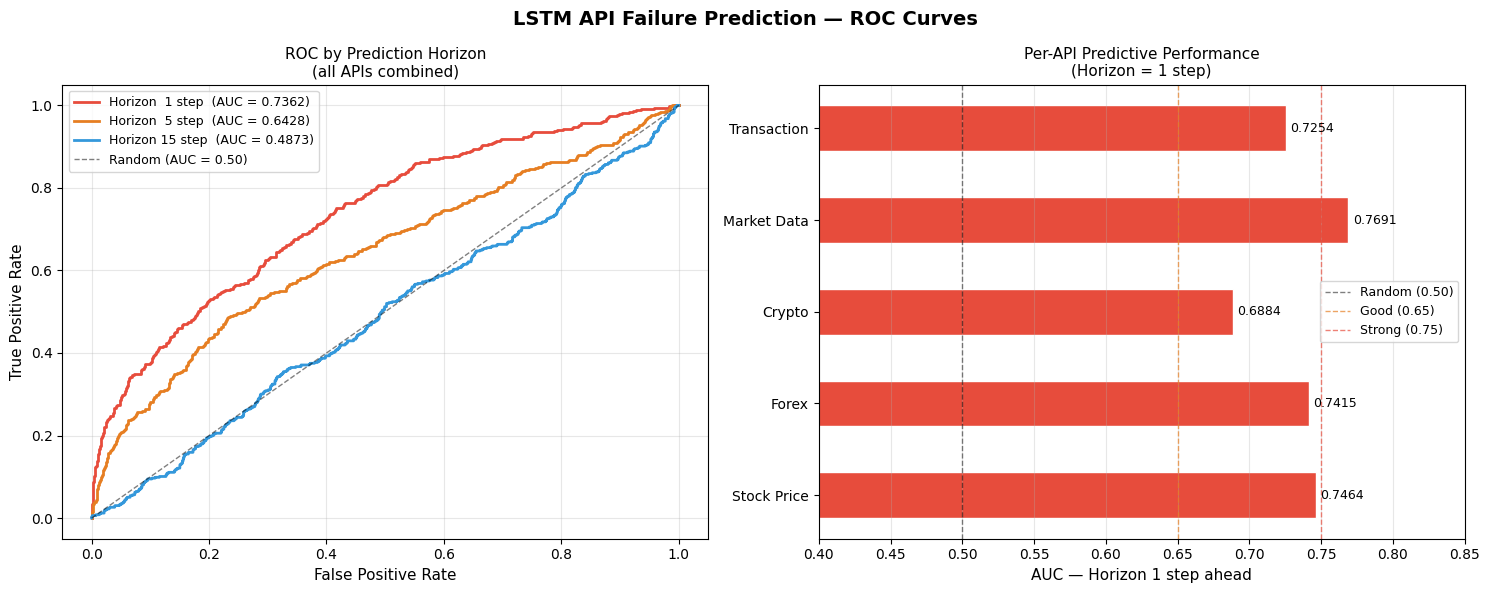

✅ ROC plot saved → models/demo_roc_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('LSTM API Failure Prediction — ROC Curves', fontsize=14, fontweight='bold')

# ── Left: ROC per prediction horizon (all APIs combined) ─────────────────────
ax = axes[0]
all_probs_cat   = np.vstack([api_datasets[a]['probs']   for a in API_TYPES])
all_targets_cat = np.vstack([api_datasets[a]['targets'] for a in API_TYPES])

colors = ['#e74c3c', '#e67e22', '#3498db']
for i, (h, col) in enumerate(zip(PREDICTION_HORIZONS, colors)):
    y_true  = all_targets_cat[:, i]
    y_score = all_probs_cat[:, i]
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_score)
        fpr, tpr, _ = roc_curve(y_true, y_score)
        ax.plot(fpr, tpr, color=col, lw=2,
                label=f'Horizon {h:>2} step  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.set_title('ROC by Prediction Horizon\n(all APIs combined)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Right: AUC bar chart per API (horizon-1) ─────────────────────────────────
ax2 = axes[1]
api_names = [s['api'].replace(' API', '') for s in api_summary]
aucs_h1   = [s['auc_h1'] for s in api_summary]
bar_colors = ['#e74c3c' if a >= RISK_HIGH
              else '#e67e22' if a >= 0.60
              else '#2ecc71' for a in aucs_h1]

bars = ax2.barh(api_names, aucs_h1, color=bar_colors, edgecolor='white', height=0.5)
ax2.axvline(0.5,  color='black',  linestyle='--', lw=1, alpha=0.5, label='Random (0.50)')
ax2.axvline(0.65, color='#e67e22', linestyle='--', lw=1, alpha=0.7, label='Good (0.65)')
ax2.axvline(0.75, color='#e74c3c', linestyle='--', lw=1, alpha=0.7, label='Strong (0.75)')
for bar, auc in zip(bars, aucs_h1):
    ax2.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
             f'{auc:.4f}', va='center', fontsize=9)
ax2.set_xlim(0.4, 0.85)
ax2.set_xlabel('AUC — Horizon 1 step ahead', fontsize=11)
ax2.set_title('Per-API Predictive Performance\n(Horizon = 1 step)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../models/demo_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC plot saved → models/demo_roc_curves.png")

## Cell 8 — Failure Probability Timeline (with Risk Bands)

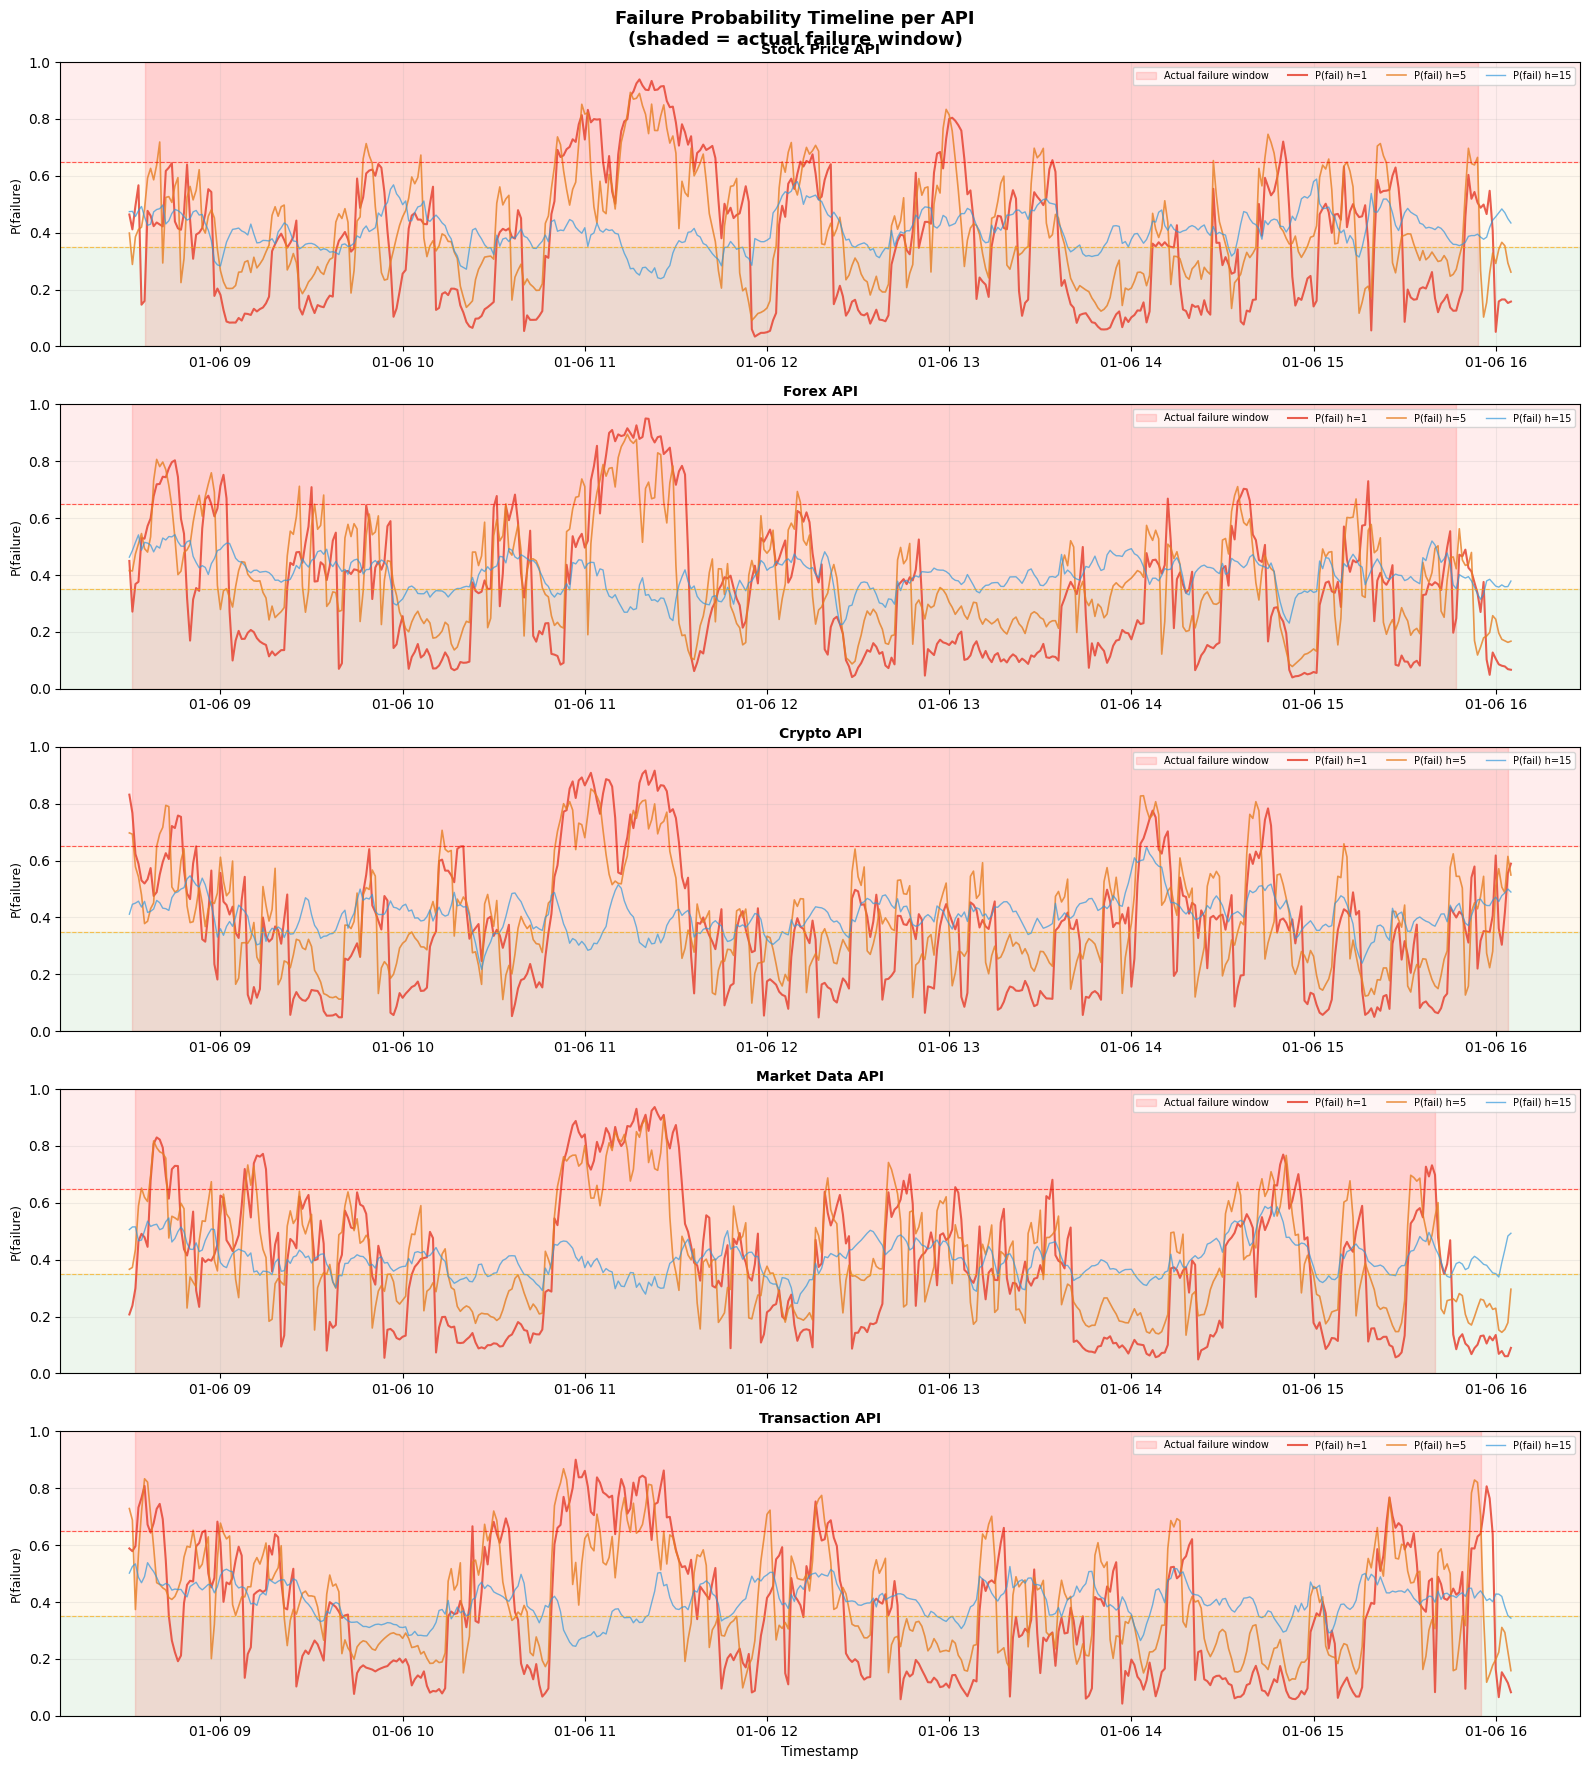

✅ Timeline plot saved → models/demo_timeline.png


In [8]:
fig, axes = plt.subplots(len(API_TYPES), 1, figsize=(16, 18), sharex=False)
fig.suptitle('Failure Probability Timeline per API\n(shaded = actual failure window)',
             fontsize=13, fontweight='bold')

for ax, api in zip(axes, API_TYPES):
    probs  = api_datasets[api]['probs']
    sub_df = api_datasets[api]['df']
    idx    = api_datasets[api]['idx']

    ts     = [sub_df.loc[i, 'timestamp'] for i in idx]
    p_h1   = probs[:, 0]
    p_h5   = probs[:, 1]
    p_h15  = probs[:, 2]

    # Actual failure regions (shaded)
    actual_fail = np.array([1 - sub_df.loc[i, 'success'] for i in idx])
    fail_ts = [t for t, f in zip(ts, actual_fail) if f == 1]
    if fail_ts:
        ax.axvspan(min(fail_ts), max(fail_ts),
                   alpha=0.12, color='red', label='Actual failure window')

    # Risk threshold bands
    ax.axhspan(RISK_HIGH, 1.0,     alpha=0.07, color='red')
    ax.axhspan(RISK_LOW,  RISK_HIGH, alpha=0.07, color='orange')
    ax.axhspan(0,         RISK_LOW,  alpha=0.07, color='green')

    ax.plot(ts, p_h1,  color='#e74c3c', lw=1.5, label='P(fail) h=1',  alpha=0.9)
    ax.plot(ts, p_h5,  color='#e67e22', lw=1.2, label='P(fail) h=5',  alpha=0.8)
    ax.plot(ts, p_h15, color='#3498db', lw=1.0, label='P(fail) h=15', alpha=0.7)

    ax.axhline(RISK_HIGH, color='red',    linestyle='--', lw=0.8, alpha=0.6)
    ax.axhline(RISK_LOW,  color='orange', linestyle='--', lw=0.8, alpha=0.6)

    ax.set_ylabel('P(failure)', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(api, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right', ncol=4)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Timestamp', fontsize=10)
plt.tight_layout()
plt.savefig('../models/demo_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Timeline plot saved → models/demo_timeline.png")

## Cell 9 — Save Full Results to JSON

In [9]:
results = {
    'demo_metadata': {
        'n_apis':         len(API_TYPES),
        'n_predictions':  int(len(pred_table)),
        'sequence_length': SEQUENCE_LENGTH,
        'horizons':       PREDICTION_HORIZONS,
        'risk_thresholds': {'low': RISK_LOW, 'high': RISK_HIGH},
    },
    'per_api_summary': [],
    'risk_distribution': {
        'HIGH':   int(n_high),
        'MEDIUM': int(n_medium),
        'LOW':    int(n_low),
    },
    'overall_auc': {},
}

# Per-API results
for s in api_summary:
    results['per_api_summary'].append({
        'api':      s['api'],
        'avg_failure_prob': round(s['avg_prob'], 4),
        'risk_level': s['risk'].split()[0],
        'auc_horizon_1': round(s['auc_h1'], 4) if not np.isnan(s['auc_h1']) else None,
    })

# Overall AUC per horizon
for i, h in enumerate(PREDICTION_HORIZONS):
    y_true  = all_targets_cat[:, i]
    y_score = all_probs_cat[:, i]
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_score)
        results['overall_auc'][f'horizon_{h}'] = round(float(auc), 4)

os.makedirs('../models', exist_ok=True)
with open(RESULTS_PATH, 'w') as f:
    json.dump(results, f, indent=2)

print("=" * 55)
print("  ✅  DEMO COMPLETE — All outputs saved")
print("=" * 55)
print(f"  📄 Prediction table : models/demo_predictions.csv")
print(f"  📊 ROC curves plot  : models/demo_roc_curves.png")
print(f"  📈 Timeline plot    : models/demo_timeline.png")
print(f"  🗃️  Results JSON     : models/demo_results.json")
print("=" * 55)
print("\n  Overall AUC Summary:")
for h_key, auc_val in results['overall_auc'].items():
    print(f"    {h_key.replace('_', ' ').title():<15} AUC = {auc_val:.4f}")

  ✅  DEMO COMPLETE — All outputs saved
  📄 Prediction table : models/demo_predictions.csv
  📊 ROC curves plot  : models/demo_roc_curves.png
  📈 Timeline plot    : models/demo_timeline.png
  🗃️  Results JSON     : models/demo_results.json

  Overall AUC Summary:
    Horizon 1       AUC = 0.7362
    Horizon 5       AUC = 0.6428
    Horizon 15      AUC = 0.4873
